# Solving the Generalized Eigenvalue Problem and plotting over k space

## Import

In [133]:
import torch
import matplotlib.pyplot as plt
from ase.dft import kpoints

from data.snapshot import Snapshot
from net.common import Config
import scipy
import numpy as np

## Load Data

In [2]:
# Load the snapshot
cfg = Config()
snapshot = Snapshot.from_openmx(
    "../../data/small/H2O/original/H2O.matrix",
    "../../data/small/H2O/original/H2O.info.out",
    cfg=cfg
)
snapshot_fhi = Snapshot.from_fhiaims(geometry_path='/Users/martin66/PycharmProjects/Mandala/data/fhi-aims/original/basis_small/geometry.in',
    basis_path='/Users/martin66/PycharmProjects/Mandala/data/fhi-aims/original/basis_small/basis-indices.out',
                                    hamiltonian_path='/Users/martin66/PycharmProjects/Mandala/data/fhi-aims/original/basis_small/H_spin_01_kpt_000001.csc',
                                    overlap_path='/Users/martin66/PycharmProjects/Mandala/data/fhi-aims/original/basis_small/S_spin_01_kpt_000001.csc',
                                    density_path='/Users/martin66/PycharmProjects/Mandala/data/fhi-aims/original/basis_small/D_spin_01_kpt_000001.csc',
                                     cfg=cfg)

In [3]:
hamiltonian = snapshot.hamiltonian
overlap = snapshot.overlap

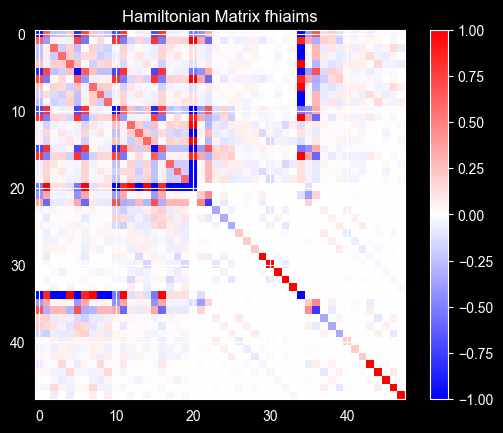

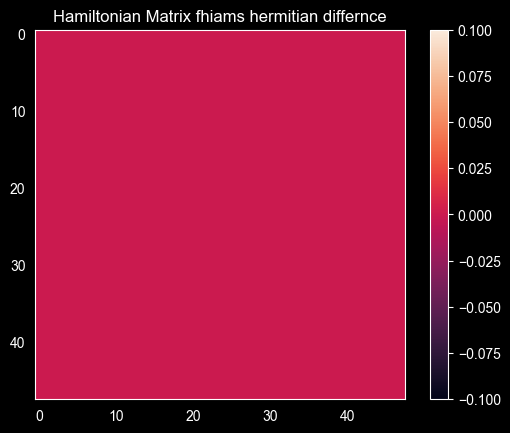

In [6]:
fhi_ham = snapshot_fhi.hamiltonian
fhi_ovlp = snapshot_fhi.overlap

fhi_ham = fhi_ham.to_dense()
fhi_ovlp = fhi_ovlp.to_dense()

plt.imshow(fhi_ham, cmap="bwr", vmin=-1, vmax=1)
plt.title("Hamiltonian Matrix fhiaims")
plt.colorbar()
plt.show()

herm_fhi_ham = .5 * (fhi_ham + fhi_ham.conj().T)
plt.imshow(torch.abs(herm_fhi_ham-fhi_ham))
plt.title("Hamiltonian Matrix fhiams hermitian differnce")
plt.colorbar()
plt.grid(None)
plt.savefig('fhiaims.png')
plt.show()

tensor([[3.3481, 0.0000, 0.0000],
        [0.0000, 3.3481, 0.0000],
        [0.0000, 0.0000, 3.2399]])
0 0 0 0 0
0 0 0 1 1
0 0 0 2 2
0 0 0 3 3
0 0 0 0 1
0 0 0 1 0
0 0 0 1 2
0 0 0 1 3
0 0 0 2 1
0 0 0 3 1
0 0 0 0 2
0 0 0 0 3
0 0 0 2 0
0 0 0 3 0
0 0 0 2 3
0 0 0 3 2
0 0 0 0 5
0 0 0 1 5
0 0 0 0 4
0 0 0 3 5
0 0 0 2 5
0 0 0 1 4
0 0 0 2 4
0 0 0 3 4
0 0 0 5 0
0 0 0 5 1
0 0 0 4 0
0 0 0 5 3
0 0 0 5 2
0 0 0 4 1
0 0 0 4 2
0 0 0 4 3
0 0 0 4 4
0 0 0 5 5
0 0 0 4 5
0 0 0 5 4


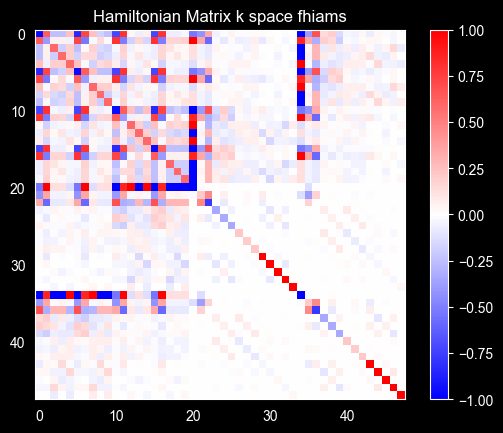

In [7]:
k = torch.tensor([0,0,0])
lattice = snapshot_fhi.box
print(lattice)
fhi_ham = snapshot_fhi.hamiltonian
fhi_ovlp = snapshot_fhi.overlap

fhi_k_ham = fhi_ham.to_dense_k(lattice,k)

plt.imshow(torch.real(fhi_k_ham),cmap="bwr", vmin=-1, vmax=1)
plt.title("Hamiltonian Matrix k space fhiams")
plt.colorbar()
plt.grid(None)
plt.show()

## Plot Hamiltonaian and Overlap

### plot in realspace

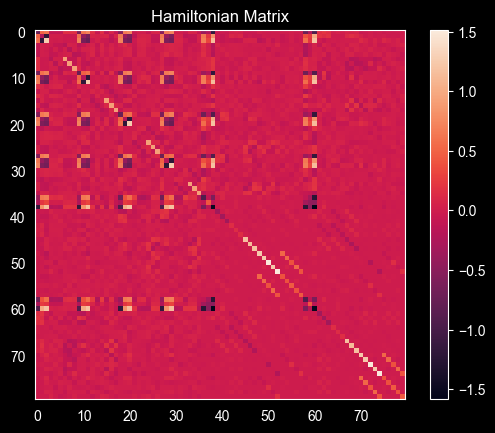

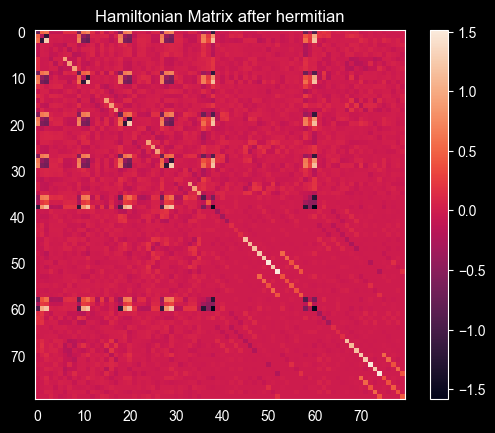

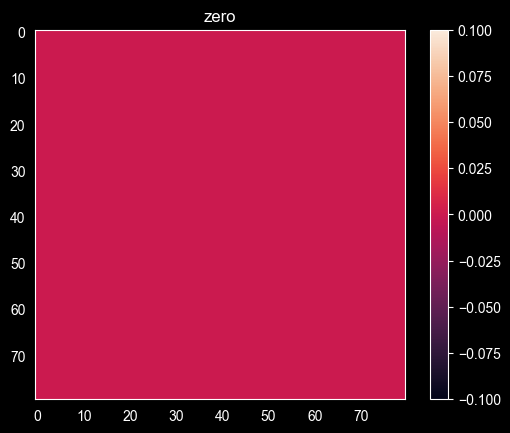

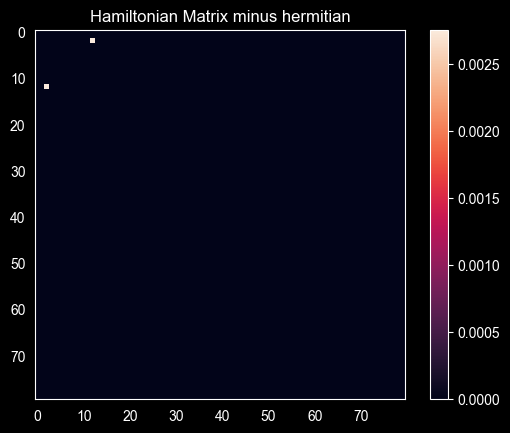

In [6]:
ham = hamiltonian.to_dense()
plt.imshow(torch.real(ham))#, cmap="bwr", vmin=-1, vmax=1)
plt.title("Hamiltonian Matrix")
plt.colorbar()
plt.grid(None)
plt.show()

ovlp = overlap.to_dense()

herm_ham = .5 * (ham + ham.conj().T)
plt.imshow(herm_ham)#, cmap="bwr", vmin=-1, vmax=1)
plt.title("Hamiltonian Matrix after hermitian")
plt.colorbar()
plt.grid(None)
plt.show()

plt.imshow(torch.abs(ham-ham))
plt.title("zero")
plt.colorbar()
plt.grid(None)
plt.show()

plt.imshow(torch.abs(ham-herm_ham))
plt.title("Hamiltonian Matrix minus hermitian")
plt.grid(None)
plt.colorbar()
plt.show()

### Plot in k space

#### Plot the overlap and hamiltonian

0 0 0 0 0
0 0 0 1 1
0 0 0 2 2
0 0 0 3 3
0 0 0 0 1
0 0 0 1 0
-1 1 0 3 2
1 -1 0 2 3
0 -1 -1 0 3
0 1 1 3 0
-1 0 -1 0 2
1 0 1 2 0
0 -1 0 2 1
0 1 0 1 2
-1 0 0 3 1
1 0 0 1 3
0 0 -1 1 3
0 0 1 3 1
0 0 -1 1 2
0 0 1 2 1
0 0 -1 0 3
0 0 1 3 0
0 0 -1 0 2
0 0 1 2 0
0 0 0 0 2
0 0 0 0 3
0 0 0 1 2
0 0 0 1 3
0 0 0 2 0
0 0 0 2 1
0 0 0 3 0
0 0 0 3 1
-1 0 1 3 1
0 -1 1 2 1
0 1 -1 1 2
1 0 -1 1 3
-1 0 0 0 2
1 0 0 2 0
0 -1 0 0 3
0 1 0 3 0
0 -1 0 2 3
0 1 0 3 2
-1 0 0 3 2
1 0 0 2 3
0 -1 0 0 1
0 1 0 1 0
-1 0 0 0 1
1 0 0 1 0
-1 -1 0 0 1
1 1 0 1 0
0 0 0 2 3
0 0 0 3 2
0 0 -1 0 0
0 0 -1 1 1
0 0 -1 2 2
0 0 -1 3 3
0 0 1 0 0
0 0 1 1 1
0 0 1 2 2
0 0 1 3 3
0 -1 0 0 0
0 -1 0 1 1
0 -1 0 2 2
0 -1 0 3 3
0 1 0 0 0
0 1 0 1 1
0 1 0 2 2
0 1 0 3 3
-1 0 0 0 0
-1 0 0 1 1
-1 0 0 2 2
-1 0 0 3 3
1 0 0 0 0
1 0 0 1 1
1 0 0 2 2
1 0 0 3 3
0 0 -1 1 0
0 0 1 0 1
-1 1 1 3 2
1 -1 -1 2 3
0 0 -1 0 1
0 0 1 1 0
-1 1 -1 3 2
1 -1 1 2 3
0 -1 -1 1 3
0 1 1 3 1
-1 0 -1 1 2
1 0 1 2 1
0 -1 0 2 0
0 1 0 0 2
-1 0 0 3 0
1 0 0 0 3
-1 0 0 1 2
0 -1 0 1 3
0 -1 1 2

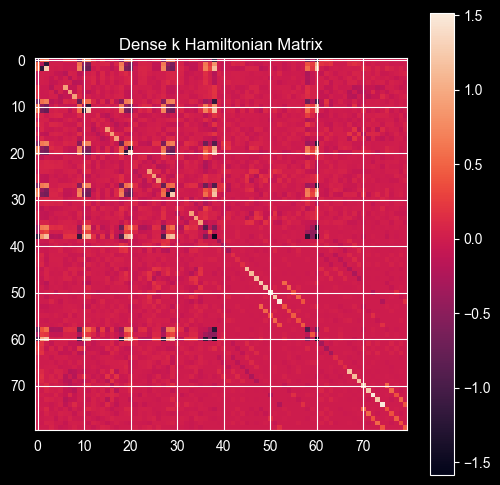

0 0 0 0 0
0 0 0 1 1
0 0 0 2 2
0 0 0 3 3
0 0 0 0 1
0 0 0 1 0
-1 1 0 3 2
1 -1 0 2 3
0 -1 -1 0 3
0 1 1 3 0
-1 0 -1 0 2
1 0 1 2 0
0 -1 0 2 1
0 1 0 1 2
-1 0 0 3 1
1 0 0 1 3
0 0 -1 1 3
0 0 1 3 1
0 0 -1 1 2
0 0 1 2 1
0 0 -1 0 3
0 0 1 3 0
0 0 -1 0 2
0 0 1 2 0
0 0 0 0 2
0 0 0 0 3
0 0 0 1 2
0 0 0 1 3
0 0 0 2 0
0 0 0 2 1
0 0 0 3 0
0 0 0 3 1
-1 0 1 3 1
0 -1 1 2 1
0 1 -1 1 2
1 0 -1 1 3
-1 0 0 0 2
1 0 0 2 0
0 -1 0 0 3
0 1 0 3 0
0 -1 0 2 3
0 1 0 3 2
-1 0 0 3 2
1 0 0 2 3
0 -1 0 0 1
0 1 0 1 0
-1 0 0 0 1
1 0 0 1 0
-1 -1 0 0 1
1 1 0 1 0
0 0 0 2 3
0 0 0 3 2
0 0 -1 0 0
0 0 -1 1 1
0 0 -1 2 2
0 0 -1 3 3
0 0 1 0 0
0 0 1 1 1
0 0 1 2 2
0 0 1 3 3
0 -1 0 0 0
0 -1 0 1 1
0 -1 0 2 2
0 -1 0 3 3
0 1 0 0 0
0 1 0 1 1
0 1 0 2 2
0 1 0 3 3
-1 0 0 0 0
-1 0 0 1 1
-1 0 0 2 2
-1 0 0 3 3
1 0 0 0 0
1 0 0 1 1
1 0 0 2 2
1 0 0 3 3
0 0 -1 1 0
0 0 1 0 1
-1 1 1 3 2
1 -1 -1 2 3
0 0 -1 0 1
0 0 1 1 0
-1 1 -1 3 2
1 -1 1 2 3
0 -1 -1 1 3
0 1 1 3 1
-1 0 -1 1 2
1 0 1 2 1
0 -1 0 2 0
0 1 0 0 2
-1 0 0 3 0
1 0 0 0 3
-1 0 0 1 2
0 -1 0 1 3
0 -1 1 2

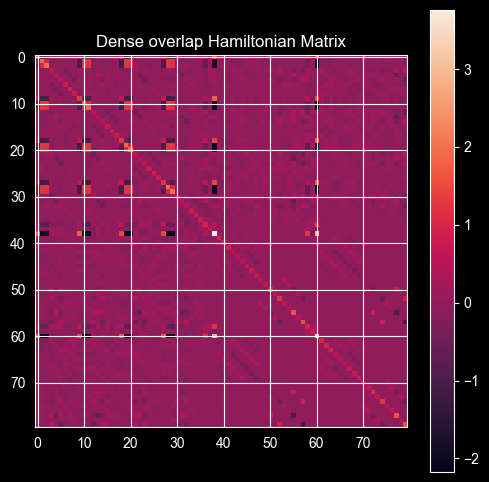

In [4]:
k = torch.tensor([0,0,0])
k_hamiltonian = hamiltonian.to_dense_k(snapshot.box,k)
plt.figure(figsize=(6, 6))
plt.imshow(torch.real(k_hamiltonian))#, cmap="bwr", vmin=-1, vmax=1)
plt.title("Dense k Hamiltonian Matrix")
plt.colorbar()
plt.show()

k_overlap = overlap.to_dense_k(snapshot.box,k)
plt.figure(figsize=(6, 6))
plt.imshow(torch.real(k_overlap))#, cmap="bwr", vmin=-1, vmax=1)
plt.title("Dense overlap Hamiltonian Matrix")
plt.colorbar()
plt.show()

#### plot the hamiltonian at zero vs another k vector

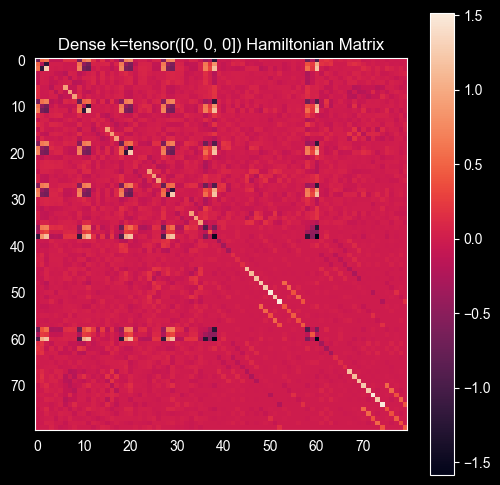

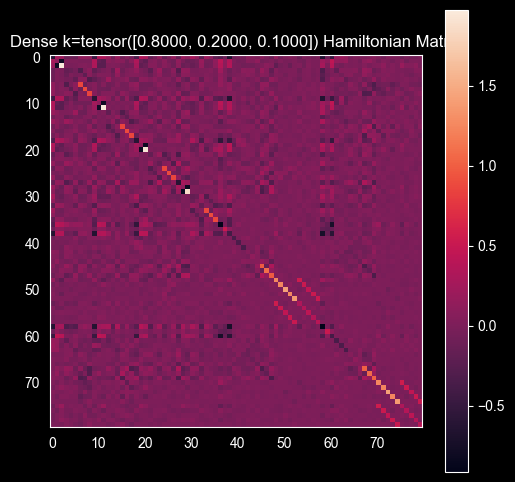

In [13]:
k = torch.tensor([0,0,0])
k_hamiltonian = hamiltonian.to_dense_k(snapshot.box,k)
plt.figure(figsize=(6, 6))
plt.imshow(torch.real(k_hamiltonian))#, cmap="bwr", vmin=-1, vmax=1)
plt.title(f"Dense k={k} Hamiltonian Matrix")
plt.colorbar()
plt.grid(None)
plt.show()

k = torch.tensor([.8,.2,.1])
k_hamiltonian = hamiltonian.to_dense_k(snapshot.box,k)
plt.figure(figsize=(6, 6))
plt.imshow(torch.real(k_hamiltonian))#, cmap="bwr", vmin=-1, vmax=1)
plt.title(f"Dense k={k} Hamiltonian Matrix")
plt.colorbar()
plt.grid(None)
plt.show()

#### compare the overlap matrices in case something there is wrong

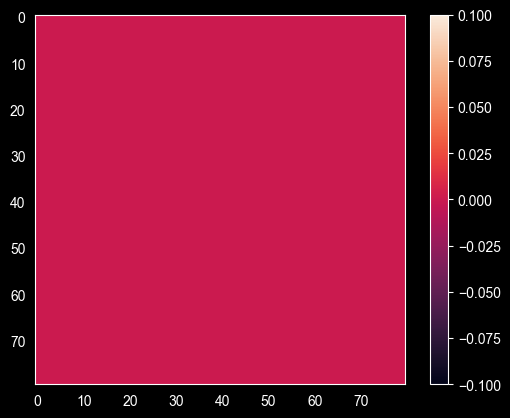

In [18]:
k = torch.tensor([0,0,0])
ovlp = overlap.to_dense()
k_ovlp = overlap.to_dense_k(snapshot.box,k)

plt.imshow(torch.real(k_ovlp-ovlp))
plt.grid(None)
plt.colorbar()
plt.show()

## Do the Eigenvalue Solve

### By hand

In [56]:
k = torch.tensor([0,0,0])

# define the block matrices
hamiltonian = snapshot.hamiltonian
overlap = snapshot.overlap

# define the k-space objects
k = torch.tensor([0,0,0])
k_hamiltonian = hamiltonian.to_dense_k(snapshot.box,k)
k_overlap = overlap.to_dense_k(snapshot.box,k)

# let us endure that the hamiltonain ans overplap are truly symetric
k_ham = .5 * (k_hamiltonian + k_hamiltonian.conj().T)
k_ovp = .5 * (k_overlap + k_overlap.conj().T)
#k_ham = k_hamiltonian
#k_ovp = k_overlap


# do cholesky decomp
L = torch.linalg.cholesky(k_ovp)

# Solve L H L^(-1) = A
X = torch.linalg.solve_triangular(L, k_ham, upper=False)
A = torch.linalg.solve_triangular(L.conj(), X.T, upper=False)

A = 0.5*(A + A.conj().T)

# eigensolve
evals, y = torch.linalg.eigh(A)

# backsolve eigenvectors as c from y
evecs = torch.linalg.solve_triangular(L.conj().T, y, upper=True)

evals_sp, evecs_sp = scipy.linalg.eigh(hamiltonian.to_dense_k(snapshot.box,k).numpy(), overlap.to_dense_k(snapshot.box,k).numpy())

In [57]:
mx_evals = torch.tensor([-0.99780907621702,
-0.93028970367958,
-0.51314335829662,
-0.51314076428901,
-0.41793614608027,
-0.32421403447690,
-0.28764988741696,
-0.28764685367954,
-0.09088945442413,
 0.11540836740208,
 0.12775306217302,
 0.23956106931152,
 0.24308731250132,
 0.24308994390605,
 0.48756733895871,
 0.48756964040648,
 0.50558099283750,
 0.62059385976573,
 0.64058572537680,
 0.65600643002373,
 0.65600701042397,
 0.70173826549983,
 0.74708376526057,
 0.88560381191905,
 0.88560414430160,
 0.96132239076825,
 1.03312849118281,
 1.04845177989077,
 1.04845524237099,
 1.19895808211366,
 1.80207706758186,
 1.84566843809575,
 1.84566920935265,
 1.90972331666620,
 1.93490081004128,
 2.00236219333304,
 2.00645319888395,
 2.00646596353041,
 2.01239558112326,
 2.03013986113486,
 2.15266225588071,
 2.15266661734307,
 2.23897373508578,
 2.27916951522846,
 2.27917010453708,
 2.34104801057933,
 2.35407921928339,
 2.41745916784069,
 2.94302552107189,
 3.01400878370975,
 3.01400944912656,
 3.05211576494571,
 3.11324699787980,
 3.11324731790521,
 3.41008098573323,
 3.50871333874089,
 3.50871434156414,
 3.54745942108409,
 3.57453540932011,
 4.08957716619361,
 4.08958148169957,
 4.12367206544026,
 4.27059471308486,
 4.84285805733347,
 4.84286035495461,
 4.99070971603856,
 5.22872091861278,
 5.37885039105689,
 5.43815293260423,
 5.43819047501548,
 5.70490676089035,
 5.79059095883714,
 5.84353621633760,
 5.92387871162914,
 5.92388119636815,
 7.70215033868934,
 8.11044839998941,
 8.11056284694693,
11.61545478225973,
12.70224394830608])

print(evals-mx_evals)

tensor([ 2.3842e-07, -2.3842e-07,  6.5565e-07,  1.3709e-06,  1.0729e-06,
         7.1526e-07,  1.1921e-07,  0.0000e+00,  6.4820e-06, -6.4820e-07,
         8.6427e-07,  2.6226e-06, -5.3346e-06,  1.2666e-06, -1.6093e-06,
         1.3828e-05, -3.5763e-07, -1.0073e-05, -1.9491e-05, -3.2604e-05,
         2.6405e-05, -2.0266e-05, -1.2136e-04, -2.3842e-05,  2.5928e-05,
        -6.1810e-05,  1.6320e-04, -4.2081e-05,  5.5671e-05, -2.9194e-04,
        -7.7486e-06, -1.1667e-03, -1.0645e-04, -1.6451e-05, -9.5248e-05,
        -4.5061e-05, -2.8396e-04,  2.0275e-03, -4.5061e-05,  4.8399e-05,
        -7.0763e-04, -3.2425e-05,  1.0085e-04, -1.5497e-04,  5.0330e-04,
        -1.0085e-04, -6.4540e-04, -3.1567e-04,  1.0943e-03, -1.2045e-03,
        -2.2507e-04, -1.1585e-03, -2.3317e-04, -1.3828e-05, -3.4523e-04,
        -3.2341e-03, -2.7227e-04, -5.0139e-04,  9.3508e-04, -9.5158e-03,
        -3.0851e-04,  1.4591e-04, -3.6659e-03, -5.5599e-03,  2.2427e-02,
        -7.1306e-03, -8.8549e-04, -1.1240e-02, -3.8

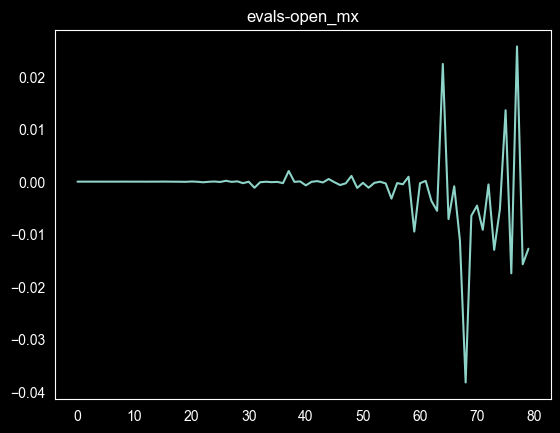

In [58]:
plt.plot(evals-mx_evals)
plt.title('evals-open_mx')
plt.grid(None)
plt.show()

### define a function

In [100]:
def generalized_eigh(H,S,eps=1e-10):
    """
    Computes the generalized eigenvalue problem of H and S.
        H c = E S c

    Parameters
    ----------
    H: Pytorch tensor, (Norbs,Norbs)
        The Hamiltonian in the orbital representation of the users
        choice. Should match the size and orbitals of the overlap.
    S: Pytorch tensor, (Norbs,Norbs)
        The Overlap matrix in the orbital representation of the users
        choice. Should match the size and orbitals of the Hamiltonian.

    Returns
    -------
    evals: Pytorch tensor, (Norbs,1)
    evacs: Pytorch tensor, (Norbs,Norbs)
    """

    # enforce that the Hamiltonian and overlap are hermitian
    H = .5 * (H+ H.conj().T)
    S = .5 * (S + S.conj().T)

    # make S non singular if it is
    S = S + torch.eye(S.shape[0])*eps

    # do cholesky decomp
    L = torch.linalg.cholesky(S)

    # Solve the generalized eigenvalue problem via S = L L^(-1)
    # L H (L.conj)^(-1) c = E c
    X = torch.linalg.solve_triangular(L, H, upper=False)
    A = torch.linalg.solve_triangular(L.conj(), X.T, upper=False)

    # make sure A is still hermitian
    A = 0.5*(A + A.conj().T)

    # solve
    evals, c = torch.linalg.eigh(A)

    # transform c back to the original basis
    c = torch.linalg.solve_triangular(L.conj().T, c, upper=True)

    return evals,c

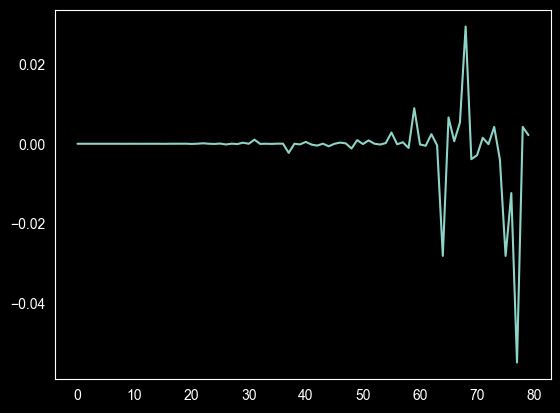

In [105]:
hamiltonian = snapshot.hamiltonian
overlap = snapshot.overlap

# define the k-space objects
k = torch.tensor([0,0,0])
Hk = hamiltonian.to_dense_k(snapshot.box,k)
Sk = overlap.to_dense_k(snapshot.box,k)

evals, evecs = generalized_eigh(Hk,Sk)

#compare to gamma point in openmx
plt.plot(mx_evals-evals)
plt.grid(None)
plt.show()

### automate for a single k vector

In [106]:
def generalized_eigh_k(snapshot,k,eps=1e-10):
    """
    Computes the generalized eigenvalue problem of H and S given a
    wavevector in fractional reciprocal coordinates.

    Parameters
    ----------
    snapshot: Block Matrix object
        Stores the hamiltonian and overlap matrix in a block
        matrix form.
    k: Pytorch tensor, (3,)
        The wave vector to compute H an S with. Must be in
        fractional reciprocal coordinates.
    eps: float
        value to add to diagonal os S to break singularity
        if it is.

    Returns
    -------

    """
    # define the k-space objects
    H = hamiltonian.to_dense_k(snapshot.box,k)
    S = overlap.to_dense_k(snapshot.box,k)

    evals, evecs = generalized_eigh(H,S,eps)

    return evals, evecs

In [316]:
def interpolate_k_path(k1,k2,points=20):
    """
    linearly interpolates k1 to k2 with a given number of points
    between them. will be an Iterator that yields the next point
    along the path.
    Parameters
    ----------
    k1: Pytorch tensor, (3,)
        the starting point of the interpolation path
    k2: Pytorch tensor, (3,)
        the ending point of the interpolation path
    points: int, optional
        The number of points along the path minus one and exclufding
        the ending point.

    Yields
    -------
    k: Pytorch tensor, (3)
        The current point along the path

    """
    ts = torch.linspace(0,1,points)

    for i,t in enumerate(ts):
        if i != points-1:
            k = (1-t)*k1 + t*k2
            yield k
        else:
            pass

def compute_k_path(snapshot,ks,points=20,eps=1e-10):
    """
    Computes the energies along the given path represented by ks.

    Parameters
    ----------
    snapshot: Block Matrix object
        Stores the hamiltonian and overlap matrix in a block
    ks: Pytorch tensor, (Nks,3)
        The target k-points along the path
    points: int, optional
        The number of points along each path segment including ends
    eps: float, optional
     value to add to diagonal os S to break singularity

    Returns
    -------

    """
    #number of segments and number of not included points
    nsegs = ks.shape[0]-1
    nskip = nsegs-1 # we skip the final point for all segments except for the last
    k_tot = (nsegs*points)-nskip

    #initalize storage for bands for a given hamiltonian
    nbands = snapshot.hamiltonian.to_dense().shape[0]
    bands = torch.empty((nbands,k_tot))
    kindx = torch.empty(ks.shape[0])
    kpts = torch.zeros((k_tot, 3))

    # iterate through path segments
    for i,k1 in enumerate(ks):

        # compute where the starting point is in the bands mat
        kindx[i] = (points-1)*i

        # second segment or last point
        if i != len(ks)-1:
            k2 = ks[i+1]
        else:
            evals,_= generalized_eigh_k(snapshot,k1,eps)
            kpts[-1,:] = k1
            bands[:,-1] = evals
            break

        # initalize a path and solve band at each point
        path = interpolate_k_path(k1,k2,points)
        for j,k in enumerate(path):

            # current index
            idx = ((points-1)*i)+j

            #compute at point in path
            kpts[idx,:] = k
            bands[:,idx],_ = generalized_eigh_k(snapshot,k,eps)

    return bands.T, kpts, kindx

In [317]:
snapshot = Snapshot.from_openmx(
    "../../data/small/H2O/original/H2O.matrix",
    "../../data/small/H2O/original/H2O.info.out",
    cfg=cfg
)

G = [0.0, 0.0, 0.0]
X = [0.5, 0.0, 0.0]
M = [0.5, 0.5, 0.0]
R = [0.5, 0.5, 0.5]

ks = torch.tensor([G, X, M, G, R, X])
print(ks)
bands,kpts,kindx = compute_k_path(snapshot,ks)

tensor([[0.0000, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.0000],
        [0.0000, 0.0000, 0.0000],
        [0.5000, 0.5000, 0.5000],
        [0.5000, 0.0000, 0.0000]])


In [328]:
print(kpts)
print(kindx)
print(torch.max(kpts))
np.save('kpath.npy',kpts.numpy())

tensor([[0.0000, 0.0000, 0.0000],
        [0.0263, 0.0000, 0.0000],
        [0.0526, 0.0000, 0.0000],
        [0.0789, 0.0000, 0.0000],
        [0.1053, 0.0000, 0.0000],
        [0.1316, 0.0000, 0.0000],
        [0.1579, 0.0000, 0.0000],
        [0.1842, 0.0000, 0.0000],
        [0.2105, 0.0000, 0.0000],
        [0.2368, 0.0000, 0.0000],
        [0.2632, 0.0000, 0.0000],
        [0.2895, 0.0000, 0.0000],
        [0.3158, 0.0000, 0.0000],
        [0.3421, 0.0000, 0.0000],
        [0.3684, 0.0000, 0.0000],
        [0.3947, 0.0000, 0.0000],
        [0.4211, 0.0000, 0.0000],
        [0.4474, 0.0000, 0.0000],
        [0.4737, 0.0000, 0.0000],
        [0.5000, 0.0000, 0.0000],
        [0.5000, 0.0263, 0.0000],
        [0.5000, 0.0526, 0.0000],
        [0.5000, 0.0789, 0.0000],
        [0.5000, 0.1053, 0.0000],
        [0.5000, 0.1316, 0.0000],
        [0.5000, 0.1579, 0.0000],
        [0.5000, 0.1842, 0.0000],
        [0.5000, 0.2105, 0.0000],
        [0.5000, 0.2368, 0.0000],
        [0.500

dtype/device: torch.float32 cpu
max |k|: 0.8660253882408142
num duplicate steps: 0
num bad k-points: 0
max_norm float32: 0.8660253882408142
max_norm float64: 0.8660254037844386
max |k component|: 0.5
argmax at row 19 component 0 value 0.5
k[row]: tensor([0.5000, 0.0000, 0.0000])


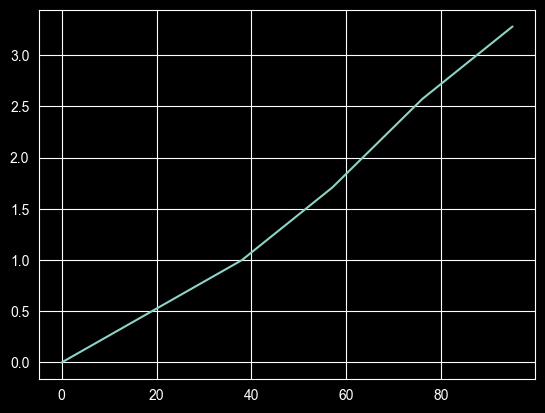

In [319]:
def cumulative_k_distance(k_points):
    k_points = np.asarray(k_points)
    dk = np.diff(k_points, axis=0)
    dist = np.linalg.norm(dk, axis=1)
    x = np.concatenate([[0.0], np.cumsum(dist)])
    return x

print("dtype/device:", kpts.dtype, kpts.device)
print("max |k|:", torch.max(torch.linalg.norm(kpts, dim=1)).item())
print("num duplicate steps:",
      torch.sum(torch.linalg.norm(kpts[1:] - kpts[:-1], dim=1) == 0).item())

kp = kpts  # (Nk,3) torch tensor

bad = ~torch.isfinite(kp).all(dim=1)          # row-wise: any NaN/Inf in the row
bad_idx = torch.nonzero(bad, as_tuple=False).flatten()

print("num bad k-points:", bad_idx.numel())
if bad_idx.numel() > 0:
    i0 = int(bad_idx[0])
    print("first bad index:", i0)
    print("k[i0]:", kp[i0])
    # show neighbors (guard edges)
    for ii in range(max(0, i0-2), min(kp.shape[0], i0+3)):
        print(ii, kp[ii])

kp32 = kpts
kp64 = kpts.to(torch.float64)

max_norm_32 = torch.max(torch.linalg.norm(kp32, dim=1))
max_norm_64 = torch.max(torch.linalg.norm(kp64, dim=1))

print("max_norm float32:", max_norm_32.item())
print("max_norm float64:", max_norm_64.item())

k_points = kpts

absmax = torch.max(torch.abs(k_points)).item()
print("max |k component|:", absmax)

# also print where it happens
flat_idx = torch.argmax(torch.abs(k_points)).item()
i = flat_idx // 3
c = flat_idx % 3
print("argmax at row", i, "component", c, "value", k_points[i, c].item())
print("k[row]:", k_points[i])


x = cumulative_k_distance(kpts)
plt.plot(x)

In [320]:
def plot_bands(x, E, tick_pos=None, tick_labels=None, Efermi=None, ylim=None, title=None):
    x = np.asarray(x)
    E = np.asarray(E)

    if Efermi is not None:
        E = E - Efermi

    fig, ax = plt.subplots()

    # Plot each band
    for b in range(E.shape[1]):
        ax.plot(x, E[:, b])

    # High-symmetry vertical lines and ticks
    if tick_pos is not None:
        for xp in tick_pos:
            ax.axvline(xp, linewidth=0.8)
        ax.set_xticks(tick_pos)
        if tick_labels is not None:
            ax.set_xticklabels(tick_labels)

    # Fermi level
    if Efermi is not None:
        ax.axhline(0.0, linestyle="--", linewidth=0.8)

    ax.set_ylabel("Energy (eV)" if Efermi is None else "Energy - $E_F$ (eV)")
    ax.set_xlabel("k-path")
    if ylim is not None:
        ax.set_ylim(*ylim)
    if title is not None:
        ax.set_title(title)

    ax.grid(True, axis="y", linewidth=0.4)
    fig.tight_layout()
    return fig, ax

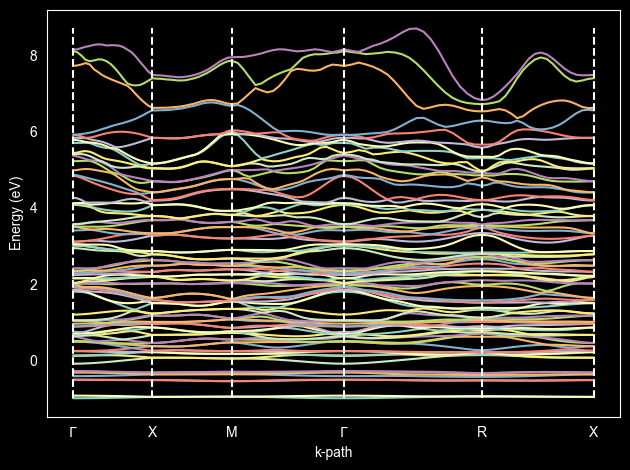

In [358]:
tbands = bands[:,:-2]
ymin = torch.min(tbands)
ymax = torch.max(tbands)
plot_bands(x,tbands)
plt.grid(None)
plt.savefig('Water_band.png')
plt.vlines(x[kindx.to(int)],ymin,ymax,linestyle="--")
plt.xticks(x[kindx.to(int)],['$\Gamma$', 'X', 'M', '$\Gamma$', 'R', 'X'])
plt.show()

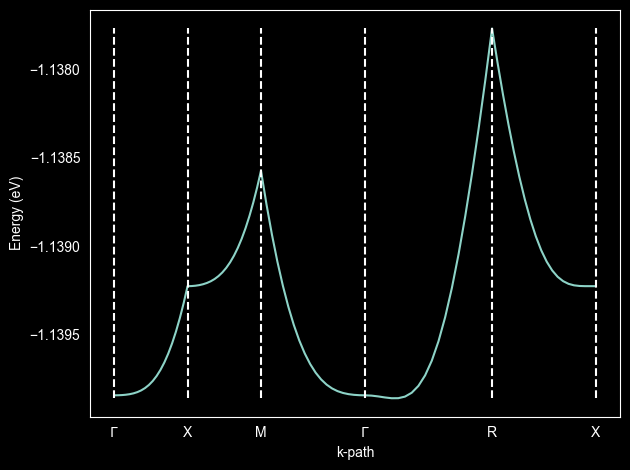

In [356]:
pyscf_bands = np.load('band_energies-3.npy')
tbands = torch.from_numpy(pyscf_bands[:,:1])
ymin = torch.min(tbands)
ymax = torch.max(tbands)
plot_bands(x,tbands)
plt.grid(None)
plt.savefig('Water_band.png')
plt.vlines(x[kindx.to(int)],ymin,ymax,linestyle="--")
plt.xticks(x[kindx.to(int)],['$\Gamma$', 'X', 'M', '$\Gamma$', 'R', 'X'])
plt.show()

In [ ]:
1